# Fish genus and species dataset

This notebook inspects the provided FishNet-style files, derives genus labels from binomial species names, checks class imbalance, demonstrates task-specific label masking, and verifies the class-stratified split used by the training pipeline.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from src.splits import make_class_stratified_splits

pd.set_option("display.max_colwidth", 100)

## Load the supplied metadata

`label_train.json` labels only the official training filenames. The official `test` and `unseen` lists are unlabeled and are prediction targets, not evaluation folds.

In [2]:
data_dir = Path("../data")
splits_dir = data_dir / "splits"

all_classes = pd.read_pickle(data_dir / "all_classes.pkl")
official_splits = {
    name: pd.read_pickle(splits_dir / f"{name}.pkl")
    for name in ("train", "test", "unseen")
}
with (data_dir / "label_train.json").open(encoding="utf-8") as handle:
    train_labels = json.load(handle)

fish = pd.DataFrame({"image_id": official_splits["train"]})
fish["species_label"] = fish["image_id"].map(train_labels)
fish["genus"] = fish["species_label"].str.split().str[0]
fish.head()

,image_id,species_label,genus
0,96566.jpg,Calloplesiops altivelis,Calloplesiops
1,939308.jpg,Calloplesiops altivelis,Calloplesiops
2,854940.jpg,Calloplesiops altivelis,Calloplesiops
3,89645.jpg,Calloplesiops altivelis,Calloplesiops
4,846185.jpg,Calloplesiops altivelis,Calloplesiops


In [3]:
summary = pd.Series({
    "all candidate species": len(all_classes),
    "labeled train images": len(fish),
    "train species": fish["species_label"].nunique(),
    "train genera": fish["genus"].nunique(),
    "unlabeled test images": len(official_splits["test"]),
    "unlabeled unseen images": len(official_splits["unseen"]),
    "missing train labels": fish["species_label"].isna().sum(),
})
summary.to_frame("count")

,count
all candidate species,17393
labeled train images,64259
train species,5795
train genera,2065
unlabeled test images,20097
unlabeled unseen images,15568
missing train labels,0


## Class imbalance

The pipeline weights classes using training-image counts. Individuals are not inferred from filenames and do not affect splitting or weighting.

In [4]:
species_counts = fish["species_label"].value_counts()
genus_counts = fish["genus"].value_counts()

pd.DataFrame({
    "species_classes": [len(species_counts)],
    "species_min": [species_counts.min()],
    "species_median": [species_counts.median()],
    "species_max": [species_counts.max()],
    "genus_classes": [len(genus_counts)],
    "genus_min": [genus_counts.min()],
    "genus_median": [genus_counts.median()],
    "genus_max": [genus_counts.max()],
})

,species_classes,species_min,species_median,species_max,genus_classes,genus_min,genus_median,genus_max
0,5795,2,2.0,281,2065,2,4.0,1697


Text(0, 0.5, 'Number of Species')

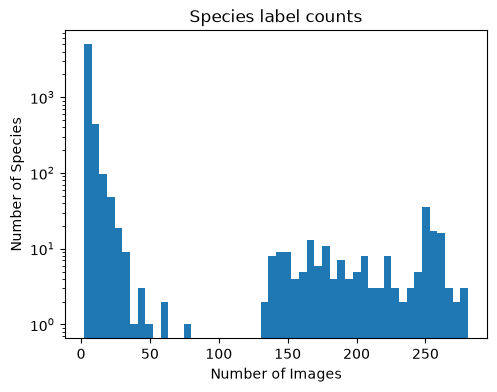

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
species_counts.plot.hist(bins=50, log=True)
plt.title("Species label counts")
plt.xlabel("Number of Images")
plt.ylabel("Number of Species")

## Mask selected classes

Species and genus masks are independent tasks. Masking a species keeps its genus supervision. By default, masking a genus also masks all species in that genus to prevent hierarchy leakage.

In [6]:
MASK_SPECIES = []  # e.g. ["Salmo salar", "Esox lucius"]
MASK_GENERA = []   # e.g. ["Lepomis", "Chaetodon"]
CASCADE_GENUS_MASK = True

masked = fish.copy()
masked.loc[masked["species_label"].isin(MASK_SPECIES), "species_label"] = pd.NA
genus_rows = masked["genus"].isin(MASK_GENERA)
masked.loc[genus_rows, "genus"] = pd.NA
if CASCADE_GENUS_MASK:
    masked.loc[genus_rows, "species_label"] = pd.NA

masked = masked[masked[["genus", "species_label"]].notna().any(axis=1)].copy()
masked["split_label"] = masked["species_label"].fillna(masked["genus"])
masked[["genus", "species_label"]].notna().sum().rename("labeled_images").to_frame()

,labeled_images
genus,64259
species_label,64259


## Verify the class-stratified split

Every retained class keeps at least one training image. Rare classes need not occur in all three folds; forcing that would discard the many species with only two images.

In [7]:
train_df, val_df, test_df = make_class_stratified_splits(
    masked,
    target_col="split_label",
    test_size=0.10,
    val_size=0.15,
    seed=42,
)

split_check = pd.DataFrame({
    "rows": [len(train_df), len(val_df), len(test_df)],
    "split classes": [
        frame["split_label"].nunique()
        for frame in (train_df, val_df, test_df)
    ],
    "species labels": [
        frame["species_label"].nunique()
        for frame in (train_df, val_df, test_df)
    ],
    "genus labels": [
        frame["genus"].nunique()
        for frame in (train_df, val_df, test_df)
    ],
}, index=["train", "validation", "internal_test"])
split_check

,rows,split classes,species labels,genus labels
train,46409,5795,5795,2065
validation,12421,5795,5795,2065
internal_test,5429,1196,1196,558


In [8]:
assert set(masked["split_label"].unique()) == set(train_df["split_label"].unique())
assert set(train_df.index).isdisjoint(val_df.index)  # frames have reset indices; paths are the real key
assert set(train_df["image_id"]).isdisjoint(val_df["image_id"])
assert set(train_df["image_id"]).isdisjoint(test_df["image_id"])
print("All retained split classes are represented in training; image IDs do not overlap.")

AssertionError: 

## Inspect class weights

Weights are inverse image frequency and normalized to mean 1 separately for genus and species.

In [ ]:
species_labels = sorted(train_df["species_label"].dropna().unique())
species_to_index = {label: index for index, label in enumerate(species_labels)}
train_species_counts = train_df["species_label"].value_counts()
species_weights = np.array([1.0 / train_species_counts[label] for label in species_labels])
species_weights = species_weights / species_weights.mean()

weight_table = pd.DataFrame({
    "species": species_labels,
    "train_images": [int((train_df["species_label"] == label).sum()) for label in species_labels],
    "class_weight": species_weights,
})
display(weight_table.sort_values("class_weight", ascending=False).head(10))
display(weight_table.sort_values("class_weight").head(10))

,species,train_images,class_weight
5772,Zaprora silenus,1,1.485485
5769,Zameus squamulosus,1,1.485485
5768,Zalieutes elater,1,1.485485
5767,Zaireichthys rotundiceps,1,1.485485
5766,Zaireichthys flavomaculatus,1,1.485485
5765,Zaireichthys dorae,1,1.485485
5763,Yunnanilus brevis,1,1.485485
5762,Yongeichthys criniger,1,1.485485
5761,Yasuhikotakia morleti,1,1.485485
31,Acanthemblemaria maria,1,1.485485


,species,train_images,class_weight
3758,Ostracion cubicum,211,0.007040
20,Abudefduf vaigiensis,210,0.007074
5199,Sphyraena barracuda,207,0.007176
464,Arothron hispidus,204,0.007282
256,Amphiprion clarkii,202,0.007354
1703,Dascyllus trimaculatus,202,0.007354
5447,Thalassoma lunare,201,0.007390
2903,Labroides dimidiatus,201,0.007390
2050,Esox lucius,198,0.007502
4793,Salmo trutta,198,0.007502


## Sweep syntax

Use `configs/experiments/fish_masking.yaml` as a runnable example. Each inner list is one complete mask value; the sweep engine forms the Cartesian product of species masks and genus masks.

```yaml
sweep:
  enabled: true
  parameters:
    data.label_masking.species:
      - []
      - ["Salmo salar"]
    data.label_masking.genus:
      - []
      - ["Lepomis"]
```

The `unseen` filenames have no supplied labels and many candidate species have no labeled training images. The supervised classifier exports closed-set predictions among training species; it cannot learn genuinely unseen species without a separate zero-shot model.